# Boiler/Turbogenerator System Optimization - Linear Programming

This notebook demonstrates process optimization using the Gurobi solver, with a focus on energy systems and industrial operations.
A flagship example included here is the Boiler–Turbogenerator System Optimization, inspired by Example 11.4 from:

Edgar, T. F., Himmelblau, D. M., and Lasdon, L. S.
Optimization of Chemical Processes, 2nd Edition, McGraw-Hill.

![Boiler/Turbogenerator System Diagram](images/steam_turbogenerator_system.png)

The example illustrates how linear programming (LP) and engineering constraints can be used to optimally allocate steam and power generation resources in an industrial utility system.

---

## Problem summary

A steam and power utility system includes:
- A boiler generating **high-pressure steam (HPS, 635 psig)**.
- Two turbo-generators:
  - **Turbine 1** (double extraction at 195 psig and 62 psig, with condensate).
  - **Turbine 2** (single extraction at 195 psig and exhaust at 62 psig, no condensate).
- Bypass valves (pressure-reducing valves) to route excess steam directly to headers.

The LP chooses steam flow rates and power generation/purchase to meet steam and power demands at minimum hourly cost.

---

## Decision variables (as used in the book)

\begin{aligned}
& I_i : inlet flowrate for
HPS : \text{high-pressure steam produced by the boiler} \\
& Z_1, Z_2 : \text{inlet steam flow to Turbine 1 and Turbine 2} \\
\end{aligned}
- `HE1`, `HE2` : extraction flow to 195 psig header from Turbine 1 and Turbine 2
- `LE1`, `LE2` : flow to 62 psig header from Turbine 1 and Turbine 2
- `C` : condensate from Turbine 1
- `BF1` : bypass flow from 635 psig to 195 psig header
- `BF2` : bypass flow from 195 psig to 62 psig header
- `MPS` : steam flow through 195 psig header
- `LPS` : steam flow through 62 psig header

Power variables (kW):
- `P1`, `P2` : power generated by Turbine 1 and Turbine 2
- `PP` : purchased power
- `EP` : “excess power” (difference from base-purchased power)

(Variable meanings and diagram key are listed with Figure E11.4.) fileciteturn5file3L33-L45

---

## Objective function

Minimize hourly operating cost:

minimize: f = 0.00261\*HPS + 0.0239\*PP + 0.00983\*EP


---

## Constraints (as listed in Example 11.4)

### Turbine 1 capacity / operating limits

\begin{aligned}
& P_1 \le 6250 \\
& P_1 \ge 2500 \\
& HE_1 \le 192{,}000 \\
& C \le 62{,}000 \\
& Z_1 - HE_1 \le 132{,}000
\end{aligned}



### Turbine 2 capacity / operating limits (from Table 11.4A)

The limits for Turbine 2:
- Max generative capacity: 9,000 kW
- Min load: 3,000 kW
- Max inlet flow: 244,000 lbm/h
- Max 62 psi exhaust: 142,000 lbm/h fileciteturn5file0L13-L17

In an LP formulation, these are typically enforced as:

\begin{aligned}
& P_2 \le 9000 \\
& P_2 \ge 3000 \\
& Z_2 \le 244{,}000 \\
& LE_2 \le 142{,}000
\end{aligned}


### Material balances


\begin{aligned}
& HPS - Z_1 - Z_2 - BF_1 = 0 \\
& Z_1 + Z_2 + BF_1 - C - MPS - LPS = 0 \\
& Z_1 - HE_1 - LE_1 - C = 0 \\
& Z_2 - HE_2 - LE_2 = 0 \\
& HE_1 + HE_2 + BF_1 - BF_2 - MPS = 0 \\
& LE_1 + LE_2 + BF_2 - LPS = 0
\end{aligned}


### Base-purchased power relationship

**EP + PP must sum to the base purchased power (12,000 kW)**.

A standard way to represent this is:
\
\begin{aligned}
PP + EP \ge 12\,000
\end{aligned}

### Demands

\
\begin{aligned}
& MPS \ge 271{,}536 \\
& LPS \ge 100{,}623 \\
& P_1 + P_2 + PP \ge 24{,}550
\end{aligned}

### Energy balances
\
\begin{aligned}
 & 1359.8I_1 -1267.8HE_1 - 1251.4LE_1 - 192 C - 3413 P_1 = 0 \\
 & 1359.8 I_2 - 1267.8 HE_2 - 1251.4 LE_2 - 3413 P_2 = 0
\end{aligned}


---

## Notebook contents (suggested outline)

1. **Problem data** (constants, bounds, demand values)
2. **Build LP model** in Gurobi (`gurobipy`)
3. **Solve** and check status
4. **Report solution** (decision variables + objective value)
5. (Optional) **Export** results to CSV

---

## How to run

### Option A — pip

```bash
pip install gurobipy jupyter
jupyter notebook
```

Open `notebook/boiler_turbogenerator_lp.ipynb` and run all cells.

### Option B — conda

```bash
conda create -n steam-lp python=3.11 -y
conda activate steam-lp
pip install gurobipy jupyter
jupyter notebook
```

---

## Notes on licensing

Gurobi requires a valid license to solve models beyond the limited capabilities of a free install. See the official Gurobi documentation for license options (academic, commercial, etc.).

---

## Reference

Edgar, T. F., Himmelblau, D. M., & Lasdon, L. S. *Optimization of Chemical Processes (2nd ed.)*, Example 11.4 (Boiler/Turbo-Generator System Optimization). fileciteturn5file3L14-L18


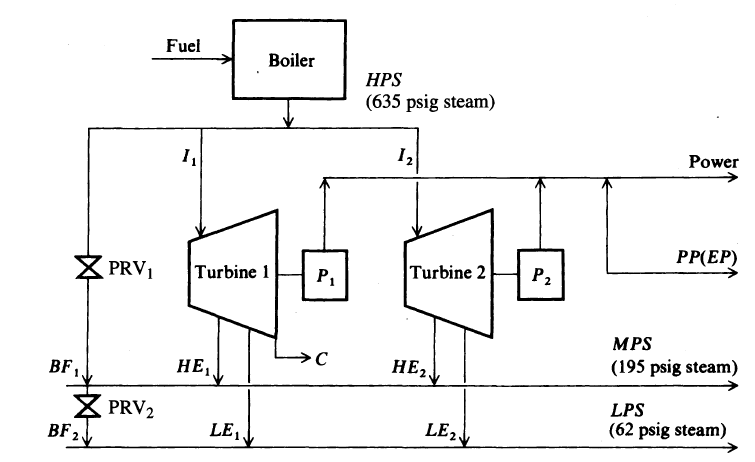

In [ ]:
!pip install gurobipy

import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # createa new model
    model = gp.Model("linear_programming")

    # create optimization or decision variables
    I1 = model.addVar(name = 'I1')
    I2 = model.addVar(name = 'I2')

    HE1 = model.addVar(name = 'HE1')
    HE2 = model.addVar(name = 'HE2')

    LE1 = model.addVar(name = 'LE1')
    LE2 = model.addVar(name = 'LE2')

    C = model.addVar(name = 'C')

    BF1 = model.addVar(name = 'BF1')
    BF2 = model.addVar(name = 'BF2')

    HPS = model.addVar(name = 'HPS')
    MPS = model.addVar(name = 'MPS')
    LPS = model.addVar(name = 'LPS')

    P1 = model.addVar(name = 'P1')
    P2 = model.addVar(name = 'P2')

    PP = model.addVar(name = 'PP')
    EP = model.addVar(name = 'EP')

    # set objective: minimize
    model.setObjective(0.00261 * HPS + 0.0239 * PP + 0.00983 * EP, GRB.MINIMIZE)

    # add constraints

    # turbine 1
    model.addConstr(P1 <= 6250, 'c1')
    model.addConstr(P1 >= 2500, 'c2')
    model.addConstr(HE1 <= 192000, 'c3')
    model.addConstr(C <= 62000, 'c4')
    model.addConstr(I1 - HE1 <= 132000, 'c5')

    # turbine 2
    model.addConstr(P2 <= 9000, 'c6')
    model.addConstr(P2 >= 3000, 'c7')
    model.addConstr(I2 <= 244000, 'c8')
    model.addConstr(LE2 <= 142000, 'c9')

    # material balances
    model.addConstr(HPS - I1 - I2 - BF1 == 0, 'c10')
    model.addConstr(I1 + I2 + BF1 - C - MPS - LPS == 0, 'c11')
    model.addConstr(I1 - HE1 - LE1 - C == 0, 'c12')
    model.addConstr(I2 - HE2 - LE2 == 0, 'c13')
    model.addConstr(HE1 + HE2 + BF1 - BF2 - MPS == 0, 'c14')
    model.addConstr(LE1 + LE2 + BF2 - LPS == 0, 'c15')

    # power purchased
    model.addConstr(EP + PP >= 12000, 'c16')

    # Demands
    model.addConstr(MPS >= 271536, 'c17')
    model.addConstr(LPS >= 100623, 'c18')
    model.addConstr(P1 + P2 + PP >= 24550, 'c19')

    # energy balances
    model.addConstr(1359.8 * I1 -1267.8 * HE1 - 1251.4 * LE1 - 192 * C - 3413 * P1 == 0, 'c20')
    model.addConstr(1359.8 * I2 -1267.8 * HE2 - 1251.4 * LE2 - 3413 * P2 == 0, 'c21')

    # optimize model
    model.optimize()

    for v in model.getVars():
        print(f"{v.VarName} {v.X:g}")

    print(f"Obj: {model.ObjVal:g}")

except gp.GurobiError as e:
    print(f"Error code {e.errno}: {e}")

except AttributeError:
    print("Encountered an attribute error")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 61.4 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 21 rows, 16 columns and 52 nonzeros (Min)
Model fingerprint: 0x99424d42
Model has 3 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [3e-03, 2e-02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+03, 3e+05]
Presolve removed 14 rows and 4 columns
Presolve time: 0.01s
Presolved: 7 rows, 12 columns, 25 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.8140000e+28   5.866406e+31   4.502400e-01      0s
       7    1.2687548e+03   0.000000e+00   0.000000e+00      0s

Solved in 7 iterations 